<a href="https://colab.research.google.com/github/khaliqtaimoor6-codes/Coronary-artery-stenosis-segmentation-/blob/main/01_data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Data conversion, EDA, frozen splits, leakage check
**What this notebook does**
1. Finds ARCADE on your Drive and **counts** what is really there (no assumptions about 1000/300/200 vs 1000/200/300).
2. Converts COCO polygons → binary masks (stenosis = lesion mask, syntax = "any vessel" mask) and caches arrays at 128 / 256 / 512 px.
3. EDA of lesion size / class imbalance.
4. **Freezes the split** into `data/splits/splits.json` (official ARCADE train/val/test + 5 folds over train+val, with a SHA-256 hash). Every later notebook loads this file and refuses to run if it was edited.
5. Perceptual-hash **near-duplicate check** across splits and across the two tasks.

Run order: top to bottom. Safe to re-run (cache and splits are skipped if they exist; set the `FORCE_*` flags to rebuild).

In [1]:
import sys, os, json, time
try:
    from google.colab import drive; drive.mount('/content/drive')
except ImportError:
    print('Not on Colab')
ROOT = os.environ.get('STENOSIS_ROOT', '/content/drive/MyDrive/stenosis_research')
sys.path.insert(0, ROOT + '/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import ndimage
import config as C, arcade_io as A
from utils import get_cache
C.make_dirs()
FORCE_CACHE  = False   # rebuild the npz caches
FORCE_SPLITS = False   # NEVER set True after you started training - it changes the experiment
ARCADE_ROOT = C.arcade_root(); print('ARCADE root:', ARCADE_ROOT)

Mounted at /content/drive
ARCADE root: /content/drive/MyDrive/arcade


## 1 · Inventory (what is actually in the dataset?)

In [3]:
rows = []
for task in C.TASKS:
    for split in ('train', 'val', 'test'):
        img_dir, js = A.split_paths(ARCADE_ROOT, task, split)
        images, anns, cats = A.load_coco(js)
        n_files = len(list(img_dir.glob('*.png')))
        rows.append(dict(task=task, split=split, png_files=n_files, coco_images=len(images),
                         annotations=len(anns), categories=len(cats), json=js.name))
inv = pd.DataFrame(rows); display(inv)
sten = inv[inv.task == 'stenosis'].set_index('split').coco_images
print('Stenosis split sizes -> train/val/test =', sten['train'], sten['val'], sten['test'])
if (sten['train'], sten['val'], sten['test']) != (1000, 200, 300):
    print('WARNING: not 1000/200/300 - check the dataset version before trusting any comparison.')

,task,split,png_files,coco_images,annotations,categories,json
0,stenosis,train,1000,1000,1625,26,train.json
1,stenosis,val,200,200,406,26,val.json
2,stenosis,test,300,300,386,26,test.json
3,syntax,train,1000,1000,4976,26,train.json
4,syntax,val,200,200,1168,26,val.json
5,syntax,test,300,300,1672,26,test.json


Stenosis split sizes -> train/val/test = 1000 200 300


## 2 · COCO → masks → cached arrays
Resizing follows the DCD-VMUNet protocol: **bilinear for images, nearest-neighbour for masks**. Native ARCADE size is 512×512.

In [4]:
def cache_path(task, size): return C.PROCESSED / f'{task}_{size}.npz'
stats = {}
for task in C.TASKS:
    if not FORCE_CACHE and all(cache_path(task, s).exists() for s in C.SIZES):
        print(task, ': cache exists, skipping'); continue
    parts = {sp: A.build_split_arrays(ARCADE_ROOT, task, sp) for sp in ('train', 'val', 'test')}
    for sp, p in parts.items():
        stats[f'{task}/{sp}'] = dict(n=len(p['keys']), annotations=p['n_annotations'],
                                     skipped_annotations=p['n_skipped_annotations'], missing_files=len(p['missing']),
                                     lesion_px_frac=float(p['masks'].mean()))
        assert not p['missing'], f'missing image files in {task}/{sp}: {p["missing"][:5]}'
    X = np.concatenate([parts[s]['images'] for s in ('train', 'val', 'test')])
    Y = np.concatenate([parts[s]['masks']  for s in ('train', 'val', 'test')])
    K = np.concatenate([parts[s]['keys']   for s in ('train', 'val', 'test')])
    assert len(set(K.tolist())) == len(K), 'duplicate keys'
    for size in C.SIZES:
        np.savez_compressed(cache_path(task, size), images=A.resize_stack(X, size, False),
                            masks=A.resize_stack(Y, size, True), keys=K)
    print(task, 'cached', X.shape)
    del X, Y, parts
# 'skipped_annotations' must be 0, otherwise some masks are incomplete
if stats: display(pd.DataFrame(stats).T)

stenosis cached (1500, 512, 512)
syntax cached (1500, 512, 512)


,n,annotations,skipped_annotations,missing_files,lesion_px_frac
stenosis/train,1000.0,1625.0,0.0,0.0,0.008107
stenosis/val,200.0,406.0,0.0,0.0,0.008628
stenosis/test,300.0,386.0,0.0,0.0,0.009759
syntax/train,1000.0,4976.0,0.0,0.0,0.033513
syntax/val,200.0,1168.0,0.0,0.0,0.036809
syntax/test,300.0,1672.0,0.0,0.0,0.036805


## 3 · EDA (stenosis task, native 512×512)

,images,empty_masks,mean_px,median_px,mean_frac,mean_lesions
split,,,,,,
test,300,0,2558.140,2218.0,0.009759,1.266667
train,1000,3,2125.132,1702.5,0.008107,1.546000
val,200,0,2261.850,2049.5,0.008628,1.885000


Overall lesion pixel fraction: 0.851%  -> predicting all-background gives ~99.15% accuracy
Lesion components: 2303; area px (512x512): min 115, median 1141, p90 2875, max 7349


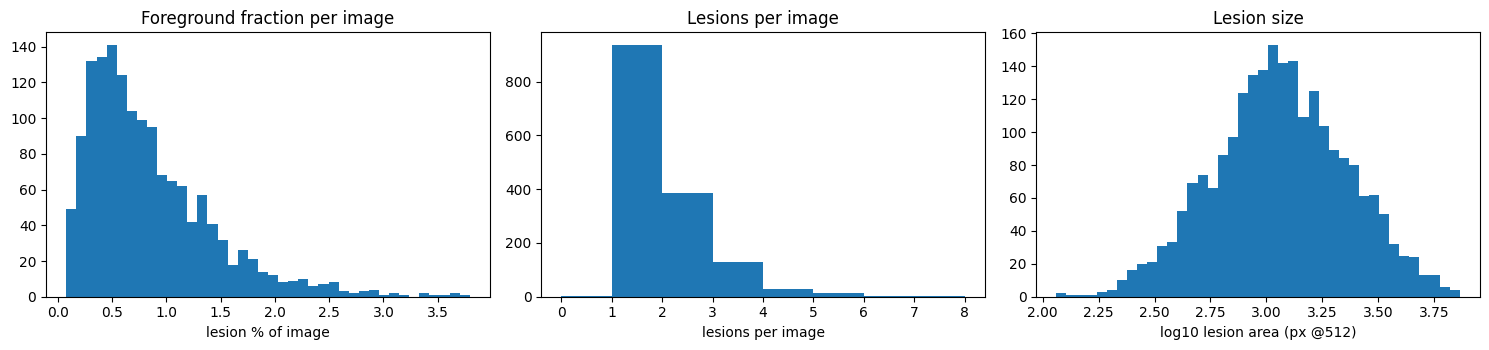

In [5]:
z = get_cache('stenosis', 512, local=False)
keys = z['keys'].tolist(); split_of = np.array([k.split('/')[0] for k in keys])
M = z['masks']
st = np.ones((3, 3), int)
rows, all_areas = [], []
for i in range(len(M)):
    lab, n = ndimage.label(M[i], structure=st)
    areas = np.bincount(lab.ravel())[1:] if n else np.array([], int)
    all_areas += areas.tolist()
    rows.append(dict(split=split_of[i], px=int(M[i].sum()), frac=M[i].mean(), n_lesions=n))
eda = pd.DataFrame(rows)
summary = eda.groupby('split').agg(images=('px', 'size'), empty_masks=('px', lambda s: int((s == 0).sum())),
                                   mean_px=('px', 'mean'), median_px=('px', 'median'),
                                   mean_frac=('frac', 'mean'), mean_lesions=('n_lesions', 'mean'))
display(summary)
print(f'Overall lesion pixel fraction: {M.mean()*100:.3f}%  -> predicting all-background gives ~{(1-M.mean())*100:.2f}% accuracy')
areas = np.array(all_areas)
print(f'Lesion components: {len(areas)}; area px (512x512): min {areas.min()}, median {np.median(areas):.0f}, p90 {np.percentile(areas, 90):.0f}, max {areas.max()}')
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(eda.frac[eda.frac > 0] * 100, bins=40); ax[0].set_xlabel('lesion % of image'); ax[0].set_title('Foreground fraction per image')
ax[1].hist(eda.n_lesions, bins=range(0, eda.n_lesions.max() + 2)); ax[1].set_xlabel('lesions per image'); ax[1].set_title('Lesions per image')
ax[2].hist(np.log10(areas), bins=40); ax[2].set_xlabel('log10 lesion area (px @512)'); ax[2].set_title('Lesion size')
plt.tight_layout(); plt.savefig(C.FIGS / '01_eda_stenosis.png', dpi=150); plt.show()
summary.to_csv(C.RESULTS / '01_eda_summary.csv')

## 4 · Freeze the split
* **Official split** = the ARCADE `train / val / test` folders (used for *all* experiments and for comparing with the papers).
* **5 folds** over train+val only (stratified by lesion size) for optional cross-validation. The test set is never inside a fold.
* Entries are `"<split>/<file_name>"` keys (file names alone can repeat across splits).
* The file stores a SHA-256 of its content; `utils.load_splits()` raises if anything changes.

In [6]:
from sklearn.model_selection import StratifiedKFold
from datetime import datetime
if C.SPLITS_FILE.exists() and not FORCE_SPLITS:
    print('splits.json already exists - NOT overwriting.')
else:
    tasks = {}
    for task in C.TASKS:
        kk = get_cache(task, 128, local=False)['keys'].tolist()
        tasks[task] = {sp: [k for k in kk if k.startswith(sp + '/')] for sp in ('train', 'val', 'test')}
    # folds over stenosis train+val, stratified by lesion-size quartile (0 = empty mask)
    tv = [i for i, k in enumerate(keys) if not k.startswith('test/')]
    px = eda.px.values[tv]
    strata = np.zeros(len(tv), int)
    pos = px > 0
    strata[pos] = pd.qcut(px[pos], 4, labels=False, duplicates='drop') + 1
    folds = []
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(tv, strata):
        folds.append(dict(train=[keys[tv[j]] for j in tr], val=[keys[tv[j]] for j in va]))
    payload = dict(tasks=tasks, folds={'stenosis': folds})
    meta = dict(version=1, created=datetime.now().isoformat(timespec='seconds'), fold_seed=42,
                note='Official ARCADE split. Do not edit. Folds are over stenosis train+val only.',
                sha256=A.canonical_sha256(payload), **payload)
    json.dump(meta, open(C.SPLITS_FILE, 'w'), indent=1)
    print('wrote', C.SPLITS_FILE)

from utils import load_splits
S = load_splits(verify=True)
print('hash OK:', S['sha256'][:16], '...')
for task in C.TASKS:
    print(task, {sp: len(v) for sp, v in S['tasks'][task].items()})
    allk = sum(S['tasks'][task].values(), [])
    assert len(allk) == len(set(allk)), 'a key appears in two splits!'
tvk = set(S['tasks']['stenosis']['train'] + S['tasks']['stenosis']['val']); tek = set(S['tasks']['stenosis']['test'])
assert not (tvk & tek)
for i, f in enumerate(S['folds']['stenosis']):
    assert not set(f['train']) & set(f['val']) and not (set(f['train'] + f['val']) & tek)
    print(f'fold {i}: train {len(f["train"])}  val {len(f["val"])}')
print('Split integrity checks passed.')

wrote /content/drive/MyDrive/stenosis_research/data/splits/splits.json
hash OK: e231362c9cb9a417 ...
stenosis {'train': 1000, 'val': 200, 'test': 300}
syntax {'train': 1000, 'val': 200, 'test': 300}
fold 0: train 960  val 240
fold 1: train 960  val 240
fold 2: train 960  val 240
fold 3: train 960  val 240
fold 4: train 960  val 240
Split integrity checks passed.


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


## 5 · Near-duplicate / leakage check
Average-hash (16×16 bits) finds candidate pairs, then a correlation check on 64×64 thumbnails confirms them.
Frames of the same patient can be near-identical, and ARCADE ships **no patient IDs**, so this check can only catch very similar frames, not guarantee patient-level separation. Treat it as a minimum.
What matters most:
* **same task, different split** → direct train/test leakage;
* **syntax ↔ stenosis** → matters for the vessel prior (a vessel model trained on syntax-train that has seen a stenosis-test image would be unfairly good on it).

In [7]:
import cv2
HASH_MAX_BITS, CORR_MIN = 12, 0.97
meta_rows, bits, thumbs = [], [], []
for task in C.TASKS:
    z = get_cache(task, 256, local=False)
    for i, k in enumerate(z['keys'].tolist()):
        img = z['images'][i]
        bits.append(A.ahash_bits(img, 16))
        t = cv2.resize(img, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()
        thumbs.append((t - t.mean()) / (t.std() + 1e-6))
        meta_rows.append(dict(task=task, split=k.split('/')[0], key=k))
meta_df = pd.DataFrame(meta_rows)
B = np.array(bits, np.float32); T = np.array(thumbs, np.float32)
Hd = B.shape[1] - (B @ B.T + (1 - B) @ (1 - B).T)           # Hamming distance matrix
iu = np.triu_indices(len(B), 1)
cand = np.where(Hd[iu] <= HASH_MAX_BITS)[0]
pairs = []
for c in cand:
    i, j = iu[0][c], iu[1][c]
    corr = float(T[i] @ T[j] / T.shape[1])
    if corr >= CORR_MIN:
        pairs.append(dict(a=meta_df.key[i], a_task=meta_df.task[i], a_split=meta_df.split[i],
                          b=meta_df.key[j], b_task=meta_df.task[j], b_split=meta_df.split[j], hamming=int(Hd[i, j]), corr=corr))
pairs = pd.DataFrame(pairs, columns=['a', 'a_task', 'a_split', 'b', 'b_task', 'b_split', 'hamming', 'corr'])
pairs.to_csv(C.RESULTS / '01_near_duplicates.csv', index=False)
print(f'{len(pairs)} near-duplicate pairs (hash<={HASH_MAX_BITS} bits and corr>={CORR_MIN}) among {len(B)} images')
if len(pairs):
    same_task_cross_split = pairs[(pairs.a_task == pairs.b_task) & (pairs.a_split != pairs.b_split)]
    cross_task = pairs[pairs.a_task != pairs.b_task]
    print('same task, different split (direct leakage):', len(same_task_cross_split))
    print('syntax <-> stenosis (prior leakage risk):    ', len(cross_task))
    display(pairs.groupby(['a_task', 'a_split', 'b_task', 'b_split']).size().rename('pairs').reset_index())
else:
    print('No near-duplicates found.')

510 near-duplicate pairs (hash<=12 bits and corr>=0.97) among 3000 images
same task, different split (direct leakage): 7
syntax <-> stenosis (prior leakage risk):     473


,a_task,a_split,b_task,b_split,pairs
0,stenosis,test,syntax,test,123
1,stenosis,train,stenosis,train,21
2,stenosis,train,stenosis,val,7
3,stenosis,train,syntax,train,252
4,stenosis,train,syntax,val,76
5,stenosis,val,stenosis,val,1
6,stenosis,val,syntax,train,21
7,stenosis,val,syntax,val,1
8,syntax,train,syntax,train,8


## 6 · Data card
If the leakage tables above are not empty, **decide now** (before any training) whether to drop those images from train. Record the decision in `splits.json` by re-creating it with `FORCE_SPLITS=True`, and tell me - do not silently edit it later.

In [8]:
card = dict(arcade_root=str(ARCADE_ROOT), sizes=list(C.SIZES), splits_sha256=S['sha256'],
            stenosis_counts={sp: len(v) for sp, v in S['tasks']['stenosis'].items()},
            syntax_counts={sp: len(v) for sp, v in S['tasks']['syntax'].items()},
            fg_pixel_fraction=float(M.mean()), near_duplicate_pairs=int(len(pairs)))
json.dump(card, open(C.RESULTS / '01_data_card.json', 'w'), indent=2); print(json.dumps(card, indent=2))

{
  "arcade_root": "/content/drive/MyDrive/arcade",
  "sizes": [
    128,
    256,
    512
  ],
  "splits_sha256": "e231362c9cb9a4172cbcfece02eaeb4d0927f448e34083e6fccf8a3876a8c1d3",
  "stenosis_counts": {
    "train": 1000,
    "val": 200,
    "test": 300
  },
  "syntax_counts": {
    "train": 1000,
    "val": 200,
    "test": 300
  },
  "fg_pixel_fraction": 0.008506632486979167,
  "near_duplicate_pairs": 510
}
